In [ ]:
# Import necessary libraries for data manipulation, visualization, and machine learning.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the hiring audit data from a CSV file into a pandas DataFrame.
df = pd.read_csv('/content/hiring_audit_data_2026.csv')

In [ ]:
# Display the entire DataFrame to inspect its structure and content.
df

,Gender,Technical_Score,KPI_Completion_Pct,Projects_done,Career_Gap_Months,Shortlisted
0,Male,86,76,5,1.7,1
1,Male,94,75,5,0.8,1
2,Female,65,76,6,12.7,0
3,Male,80,62,3,3.0,1
4,Male,85,95,3,0.9,1
...,...,...,...,...,...,...
1495,Male,67,90,5,4.8,1
1496,Female,83,99,5,5.6,1
1497,Female,60,61,6,2.6,1
1498,Male,85,78,6,2.3,1


In [ ]:
# Print a concise summary of the DataFrame, including data types, non-null counts, and memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              1500 non-null   object 
 1   Technical_Score     1500 non-null   int64  
 2   KPI_Completion_Pct  1500 non-null   int64  
 3   Projects_done       1500 non-null   int64  
 4   Career_Gap_Months   1500 non-null   float64
 5   Shortlisted         1500 non-null   int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 70.4+ KB


In [ ]:
# Check for and count the total number of missing values across the entire DataFrame.
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# Check for and count the total number of duplicate rows in the DataFrame.
df.duplicated().sum()

np.int64(0)

# **Bias Discovery**

In [ ]:
#calculate hiring rate by gender
bias_check = df.groupby('Gender')['Shortlisted'].mean()

In [ ]:
# Print the calculated hiring rates for each gender.
print(f'Hiring Rates :\n{bias_check}')

Hiring Rates :
Gender
Female    0.606452
Male      0.976552
Name: Shortlisted, dtype: float64


In [ ]:
# Calculate the Adverse Impact Ratio (AIR) by dividing the female hiring rate by the male hiring rate.
# An AIR below 0.80 indicates potential bias.
air = bias_check['Female']/bias_check['Male']
print(f'Initial Adverse Impact Ratio:{air:.2f}')    #as AIR is coming 0.62 which is bias it should be not less than 0.8

Initial Adverse Impact Ratio:0.62


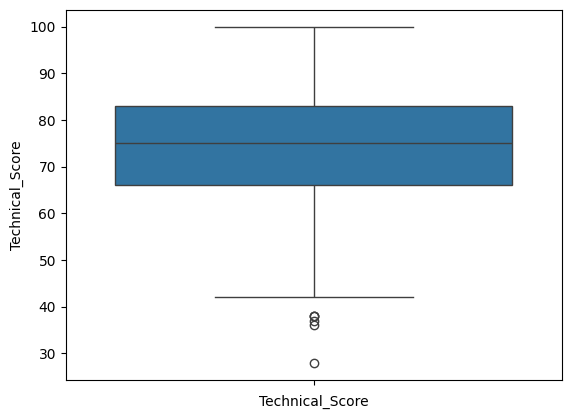

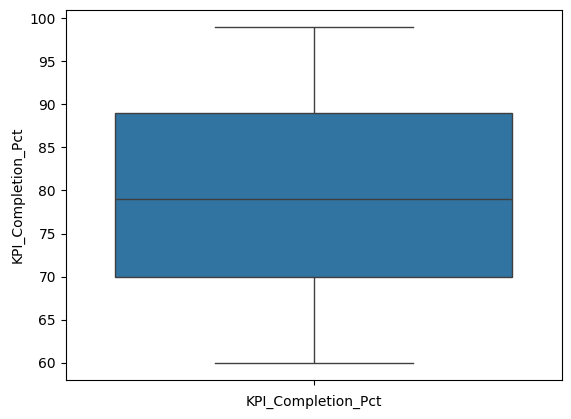

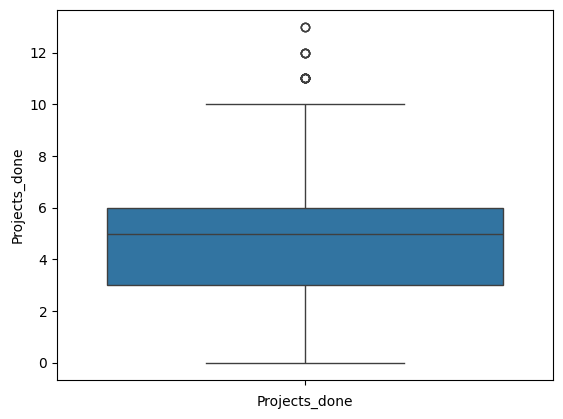

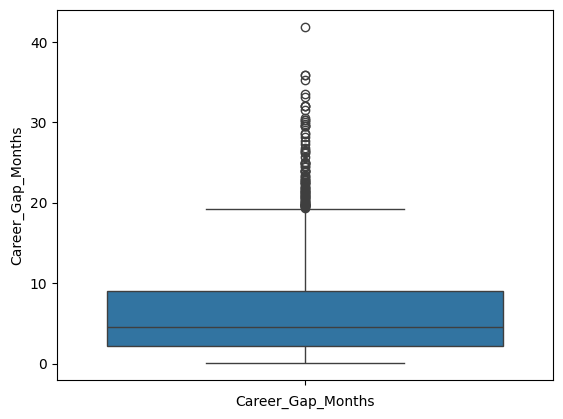

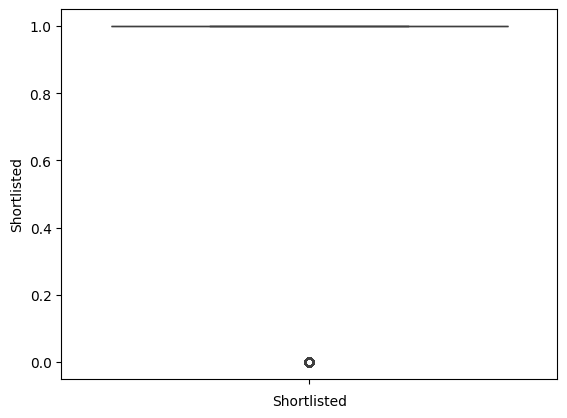

In [ ]:
# Iterate through numerical columns and generate box plots to visually identify outliers.
for col in df.columns :
  if (df[col].dtype!='object'):
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
# Define a list of columns where outliers will be treated.
out_list=['Technical_Score','Projects_done','Career_Gap_Months']
for col in out_list:
  # Calculate the first quartile (Q1) and third quartile (Q3).
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

  # Calculate the Interquartile Range (IQR).
  IQR= Q3-Q1

  # Define the Lower Bound (LB) and Upper Bound (UB) for outlier detection.
  LB = Q1-1.5*(IQR)
  UB = Q3+1.5*(IQR)

  # Filter the DataFrame to remove rows with values outside the LB-UB range.
  df=df[(df[col]>=LB) & (df[col]<=UB)]

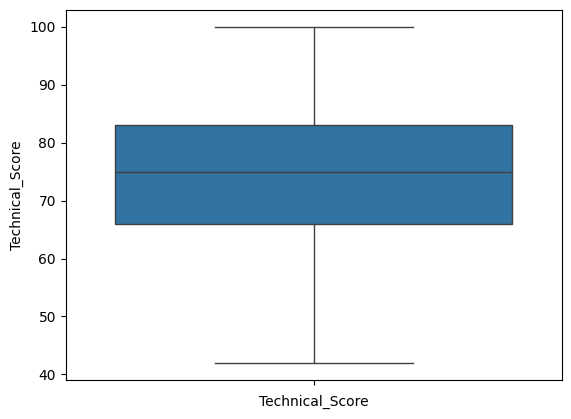

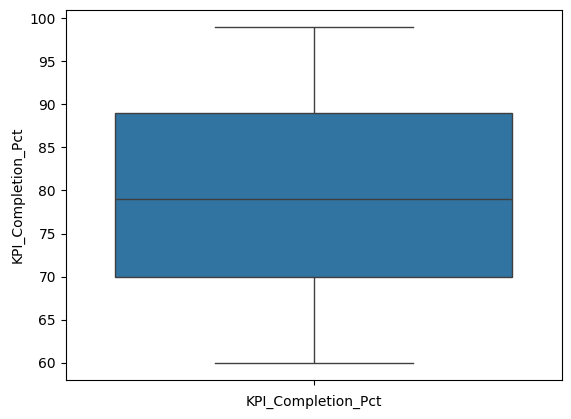

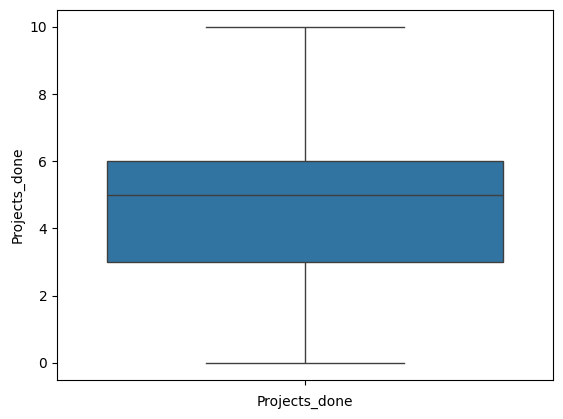

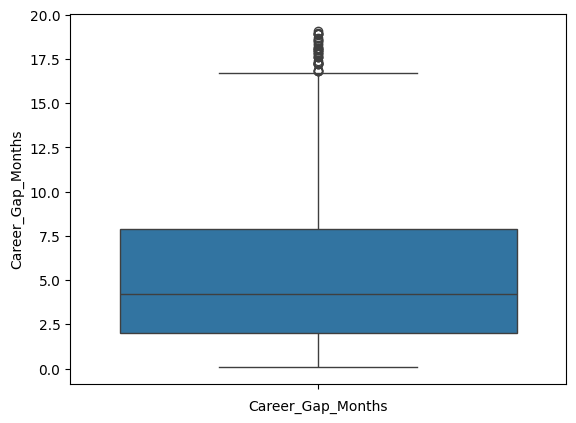

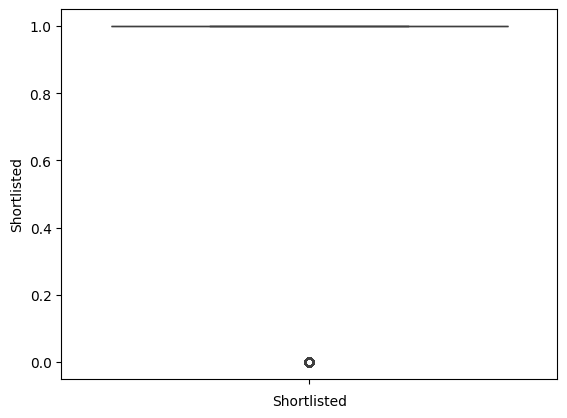

In [ ]:
# After outlier removal, re-generate box plots to visually confirm their treatment.
for col in df.columns :
  if (df[col].dtype!='object'):
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
# Import the LabelEncoder from scikit-learn for converting categorical labels to numerical.
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Initialize an instance of the LabelEncoder.
LE = LabelEncoder()

In [ ]:
# Iterate through DataFrame columns and apply label encoding to 'object' type (categorical) columns.
# This converts them into numerical representations.
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=LE.fit_transform(df[col])

In [ ]:
# Display the DataFrame after label encoding to verify that categorical columns now contain numerical values.
df

,Gender,Technical_Score,KPI_Completion_Pct,Projects_done,Career_Gap_Months,Shortlisted
0,1,86,76,5,1.7,1
1,1,94,75,5,0.8,1
2,0,65,76,6,12.7,0
3,1,80,62,3,3.0,1
4,1,85,95,3,0.9,1
...,...,...,...,...,...,...
1495,1,67,90,5,4.8,1
1496,0,83,99,5,5.6,1
1497,0,60,61,6,2.6,1
1498,1,85,78,6,2.3,1


In [ ]:
# Count the occurrences of each unique value in the 'Shortlisted' target column to assess class distribution.
df["Shortlisted"].value_counts()


,count
Shortlisted,
1,1162
0,223


In [ ]:
# Print an updated summary of the DataFrame's structure, data types, and non-null counts after cleaning and transformations.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1385 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              1385 non-null   int64  
 1   Technical_Score     1385 non-null   int64  
 2   KPI_Completion_Pct  1385 non-null   int64  
 3   Projects_done       1385 non-null   int64  
 4   Career_Gap_Months   1385 non-null   float64
 5   Shortlisted         1385 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 75.7 KB


In [ ]:
# Re-calculate hiring rates by gender using the cleaned and transformed DataFrame.
bias_check = df.groupby('Gender')['Shortlisted'].mean()
print(f'Hiring Rates :\n{bias_check}')

# Calculate and print the updated Adverse Impact Ratio (AIR).
# Assuming Gender 0 is Female and 1 is Male after encoding.
air = bias_check[0]/bias_check[1]
print(f'Initial Adverse Impact Ratio:{air:.3f}')

Hiring Rates :
Gender
0    0.690691
1    0.976356
Name: Shortlisted, dtype: float64
Initial Adverse Impact Ratio:0.707


In [ ]:
# Separate the DataFrame into independent variables (features 'x') and the target variable ('y').
x=df.drop('Shortlisted',axis= 1)
y=df['Shortlisted']

In [ ]:
# Display the DataFrame 'x' containing only the independent features.
x

,Gender,Technical_Score,KPI_Completion_Pct,Projects_done,Career_Gap_Months
0,1,86,76,5,1.7
1,1,94,75,5,0.8
2,0,65,76,6,12.7
3,1,80,62,3,3.0
4,1,85,95,3,0.9
...,...,...,...,...,...
1495,1,67,90,5,4.8
1496,0,83,99,5,5.6
1497,0,60,61,6,2.6
1498,1,85,78,6,2.3


In [ ]:
# Display the Series 'y' containing the target variable.
y

,Shortlisted
0,1
1,1
2,0
3,1
4,1
...,...
1495,1
1496,1
1497,1
1498,1


In [ ]:
# Initialize an empty pandas DataFrame to store VIF (Variance Inflation Factor) results.
vif_data=pd.DataFrame()

In [ ]:
# Display the newly created empty 'vif_data' DataFrame.
vif_data

""


In [ ]:
# Retrieve and display the names of the columns (features) in DataFrame 'x'.
x.columns

Index(['Gender', 'Technical_Score', 'KPI_Completion_Pct', 'Projects_done',
       'Career_Gap_Months'],
      dtype='object')

In [ ]:
# Populate the 'Features' column in 'vif_data' with the names of the features from 'x'.
vif_data['Features']=x.columns

In [ ]:
# Display the 'vif_data' DataFrame, now containing the feature names.
vif_data

,Features
0,Gender
1,Technical_Score
2,KPI_Completion_Pct
3,Projects_done
4,Career_Gap_Months


In [ ]:
# Import the 'variance_inflation_factor' function to calculate VIF.
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Initialize an empty list to store calculated VIF values.
vif_value=[]
# Loop through each feature (column) in 'x' to calculate its VIF.
for i in range (len(x.columns)):
  vif=variance_inflation_factor(x.values,i)
  vif_value.append(vif)

# Add the list of VIF values as a new column 'Vif_Values' to 'vif_data'.
vif_data['Vif_Values']=vif_value

In [ ]:
# Display the 'vif_data' DataFrame with the initial VIF values for all features.
# High VIF values (e.g., >5 or >10) indicate multicollinearity.
vif_data

,Features,Vif_Values
0,Gender,2.970049
1,Technical_Score,25.930660
2,KPI_Completion_Pct,26.174687
3,Projects_done,6.084360
4,Career_Gap_Months,3.492727


In [ ]:
# Drop the 'KPI_Completion_Pct' column from 'x' in place, as it showed high multicollinearity.
x.drop('KPI_Completion_Pct',axis=1,inplace=True)

In [ ]:
# Re-initialize 'vif_data' and recalculate VIF values for the remaining features after dropping 'KPI_Completion_Pct'.
vif_data=pd.DataFrame()
vif_data['Features']=x.columns

vif_value=[]
for i in range (len(x.columns)):
  vif=variance_inflation_factor(x.values,i)
  vif_value.append(vif)

vif_data['Vif_Values']=vif_value

In [ ]:
# Display the updated 'vif_data' DataFrame. 'Technical_Score' still exhibits a relatively high VIF.
vif_data

,Features,Vif_Values
0,Gender,2.892919
1,Technical_Score,9.728530
2,Projects_done,5.779146
3,Career_Gap_Months,3.356903


In [ ]:
# Drop the 'Technical_Score' column from 'x' in place, as it still indicated high multicollinearity.
x.drop('Technical_Score',axis=1,inplace=True)

In [ ]:
# Re-initialize 'vif_data' and recalculate VIF values for the final set of features.
vif_data=pd.DataFrame()
vif_data['Features']=x.columns

vif_value=[]
for i in range (len(x.columns)):
  vif=variance_inflation_factor(x.values,i)
  vif_value.append(vif)

vif_data['Vif_Values']=vif_value

In [ ]:
# Display the 'vif_data' DataFrame with the final VIF values.
# All remaining features now have acceptable VIF scores, indicating low multicollinearity.
vif_data

,Features,Vif_Values
0,Gender,2.026543
1,Projects_done,3.663552
2,Career_Gap_Months,2.221762


In [ ]:
# Import the 'train_test_split' function for dividing the dataset into training and testing subsets.
from sklearn.model_selection import train_test_split

In [ ]:
# Perform an initial split of the features ('x') and target ('y') into 80% training and 20% testing sets.
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.80)

In [ ]:
# Display a portion of the 'x_train' DataFrame, which contains the features allocated for model training.
x_train

,Gender,Projects_done,Career_Gap_Months
407,1,7,2.6
600,1,3,1.3
1382,1,9,1.1
1479,1,4,1.1
651,0,3,4.3
...,...,...,...
797,0,5,4.3
312,1,4,3.2
1266,1,4,1.7
1120,1,3,0.1


In [ ]:
# Import the SMOTE (Synthetic Minority Over-sampling Technique) class to handle class imbalance.
from imblearn.over_sampling import SMOTE

# Re-define 'x' to explicitly include only the final selected features.
x=df[["Gender","Projects_done", "Career_Gap_Months"]]
# Re-define 'y' as the target variable.
y=df["Shortlisted"]

# Split the (re-defined) data into training and testing sets.
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.80)

# Initialize an instance of SMOTE.
smote=SMOTE()

# Apply SMOTE to the training data to oversample the minority class,
# resulting in 'x_train_new' and 'y_train_new' with balanced class distributions.
x_train_new,y_train_new=smote.fit_resample(x_train,y_train)

In [ ]:
# Import the LogisticRegression class from scikit-learn for building the classification model.
from sklearn.linear_model import LogisticRegression

In [ ]:
# Initialize an instance of the LogisticRegression model.
LR=LogisticRegression()

In [ ]:
# Train the LogisticRegression model using the oversampled training features ('x_train_new') and target ('y_train_new').
LR.fit(x_train_new,y_train_new)

LogisticRegression()

In [ ]:
# Use the trained Logistic Regression model to make predictions on the unseen test features ('x_test').
y_pred=LR.predict(x_test)

In [ ]:
# Import the 'f1_score' metric for model evaluation.
from sklearn.metrics import f1_score

# Calculate the F1-score between the true test labels ('y_test') and the predicted labels ('y_pred'),
# then multiply by 100 to express it as a percentage.
f1_score(y_test,y_pred)*100

94.66666666666667

In [ ]:
# Recalculate and display hiring rates by gender using the cleaned DataFrame ('df') to assess post-cleaning bias.
bias_check = df.groupby('Gender')['Shortlisted'].mean()
print(f'Hiring Rates :\n{bias_check}')


Hiring Rates :
Gender
0    0.690691
1    0.976356
Name: Shortlisted, dtype: float64


In [ ]:
# Calculate the Adverse Impact Ratio (AIR) using the hiring rates obtained from the cleaned DataFrame ('bias_check').
air = bias_check[0]/bias_check[1]
# Print the calculated AIR after data cleaning and feature engineering, formatted to three decimal places.
print(f'Initial Adverse Impact Ratio:{air:.3f}')

Initial Adverse Impact Ratio:0.707


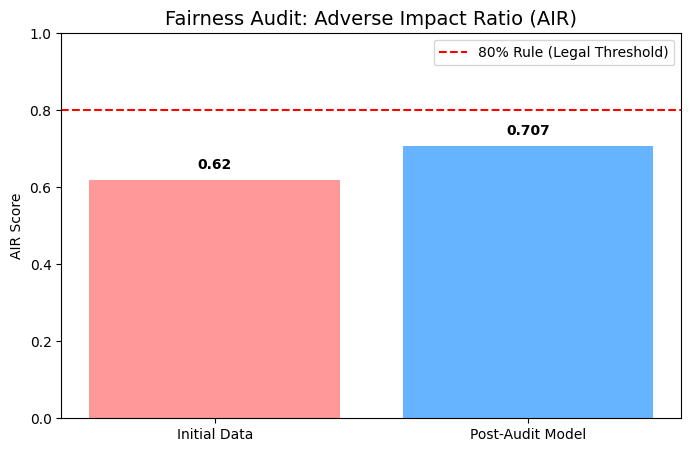

In [ ]:
# Data for the Fairness Gap (AIR Comparison) visualization.
labels = ['Initial Data', 'Post-Audit Model']
air_values = [0.62, 0.707]
plt.figure(figsize=(8, 5))
colors = ['#ff9999', '#66b3ff']
# Create a bar chart comparing initial and post-audit AIR values.
bars = plt.bar(labels, air_values, color=colors)

# Add a horizontal dashed red line at 0.80, representing the legal fairness threshold (80% rule).
plt.axhline(y=0.80, color='r', linestyle='--', label='80% Rule (Legal Threshold)')

# Set the title and labels for the plot.
plt.title('Fairness Audit: Adverse Impact Ratio (AIR)', fontsize=14)
plt.ylabel('AIR Score')
plt.ylim(0, 1)
plt.legend()

# Add the AIR value as text on top of each bar.
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval}', ha='center', va='bottom', fontweight='bold')

# Display the plot.
plt.show()

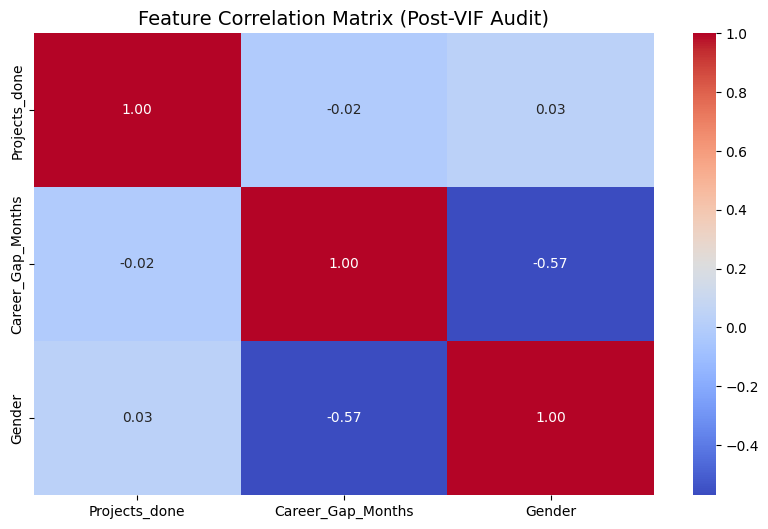

In [ ]:
# Select the final features (after VIF analysis) for the correlation heatmap.
final_features =df[['Projects_done','Career_Gap_Months','Gender']]
plt.figure(figsize=(10,6))
# Generate a heatmap of the correlation matrix for the 'final_features'.
# 'annot=True' displays correlation values, 'cmap='coolwarm'' sets the color scheme, and 'fmt='.2f'' formats annotations.
sns.heatmap(final_features.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Feature Correlation Matrix (Post-VIF Audit)',fontsize=14)
plt.show()

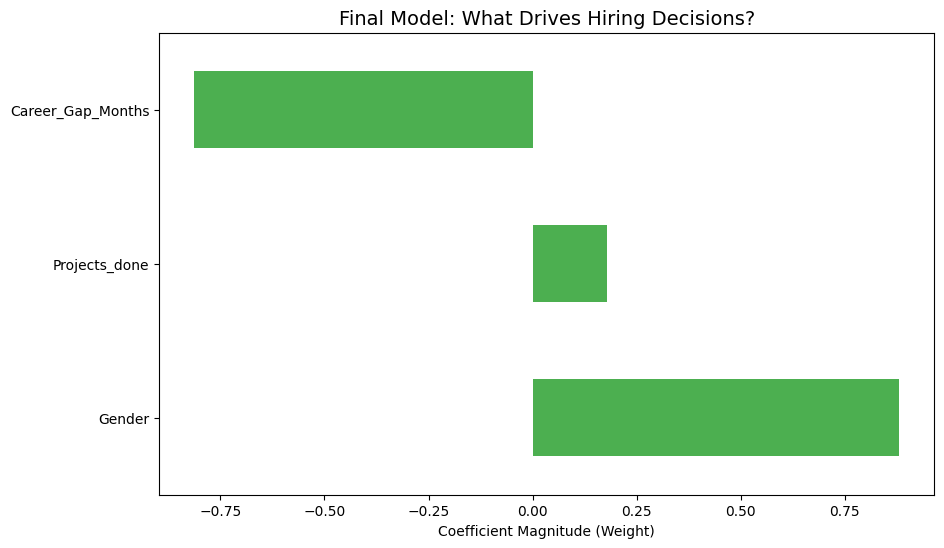

In [ ]:
# Extract the coefficients from the trained Logistic Regression model, indicating feature importance.
importance = LR.coef_[0]
# Get the names of the features.
feature_names = x.columns

# Create a pandas Series mapping feature names to their importance scores.
feat_importances = pd.Series(importance, index=feature_names)

plt.figure(figsize=(10, 6))
# Create a horizontal bar plot of the top 10 most important features (sorted by coefficient magnitude).
feat_importances.nlargest(10).plot(kind='barh', color='#4CAF50')
plt.title('Final Model: What Drives Hiring Decisions?', fontsize=14)
plt.xlabel('Coefficient Magnitude (Weight)')
plt.show()

In [ ]:
# Execute a shell command to list all installed Python packages and their versions,
# and redirect the output to a file named 'requirements.txt'. This helps in reproducing the environment.
!pip freeze >requirements.txt